# Student Mental Health Risk Screening with SVM

## Business Context
University counseling centers need scalable tools to identify students at risk of mental health issues. This project uses SVM with three kernel functions to classify high-risk vs low-risk students based on survey data.

**Key objectives:**
- Handle continuous psychological indicators
- Compare linear vs polynomial vs RBF kernels
- Hyperparameter tuning with GridSearchCV


### 🧩 一、案例背景说明

随着大学生学业压力、就业压力和社会适应问题的增加，心理健康问题成为高校关注的重要议题。
心理咨询中心通常通过问卷调查或体检系统收集学生数据，如：

    学习压力感、睡眠质量、社交频率、自我效能感、焦虑与抑郁评分等。

学校希望通过这些指标，建立一个 SVM分类模型，
自动识别出“心理健康风险学生”（high-risk vs low-risk），
以便心理辅导老师提前干预。

### 二、案例任务目标

**任务**：

基于提供的心理健康调查数据（或模拟数据），完成从数据读取到SVM建模的完整过程：

**1. 数据准备与可视化**

    - 从本地读取 mental_health_survey.csv

    - 检查缺失值、异常值并可视化主要特征分布

**2. 数据预处理**

    - 对连续特征进行标准化

    - 对分类变量进行编码（如性别、年级）

    - 划分训练集与测试集

**3. 模型构建与训练**

    - 使用 SVC 构建三种核函数模型：线性、多项式、RBF

    - 对比三种核函数下的分类准确率

**4. 模型评估与解释**

    - 计算 Accuracy、Recall、F1、AUC

    - 绘制混淆矩阵与ROC曲线

    - 对参数 C 与 γ 进行网格调优（GridSearchCV）

**5. 模型可视化与总结**

    - 可视化决策边界（选2个关键特征）

    - 总结最优模型及其在心理健康筛查中的意义

# 1.数据准备与可视化

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =====================================
# Step 1. 数据准备与检查 (Mental Health)
# =====================================

# 设置matplotlib显示中文和负号 (沿用你的设置)
plt.rcParams['font.sans-serif'] = ['Heiti TC']  # 指定默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False   # 解决保存图像时负号'-'

df = pd.read_csv("../datasets/mental_health_survey.csv")
print("\n数据概览：")
df.info()

# --- 检查缺失值 ---
print("\n缺失值统计：")
print(df.isnull().sum()) 


# --- 4. 检查异常值 (针对数值型特征) ---
print("\n数值型特征的描述性统计 (用于发现异常值)：")
print(df.describe())




数据概览：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   study_pressure    800 non-null    int64  
 1   sleep_quality     800 non-null    int64  
 2   social_frequency  800 non-null    int64  
 3   self_efficacy     800 non-null    int64  
 4   anxiety_score     800 non-null    float64
 5   depression_score  800 non-null    float64
 6   age               800 non-null    int64  
 7   gender            800 non-null    object 
 8   risk              800 non-null    int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 56.4+ KB

缺失值统计：
study_pressure      0
sleep_quality       0
social_frequency    0
self_efficacy       0
anxiety_score       0
depression_score    0
age                 0
gender              0
risk                0
dtype: int64

数值型特征的描述性统计 (用于发现异常值)：
       study_pressure  sleep_quality  social_frequency  self_effic

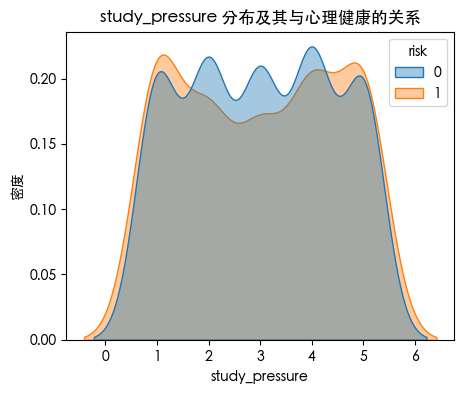

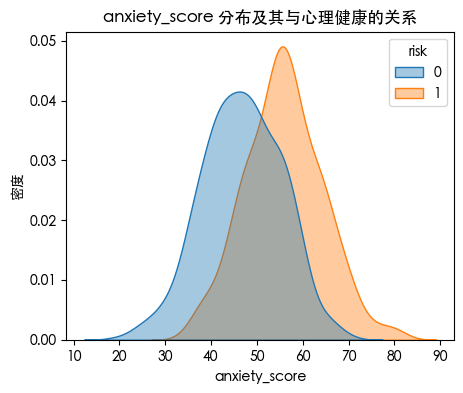

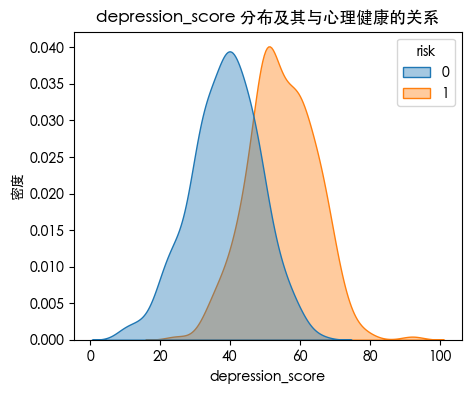

In [12]:
# 可视化关键特征分布（如血糖、BMI、年龄）
features_to_plot = ["study_pressure", "anxiety_score", "depression_score"]
for feat in features_to_plot:
    plt.figure(figsize=(5,4))
    sns.kdeplot(data=df, x=feat, hue="risk", fill=True, common_norm=False, alpha=0.4)
    plt.title(f"{feat} 分布及其与心理健康的关系")
    plt.xlabel(feat)
    plt.ylabel("密度")
    plt.show()


# 2.数据预处理

In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt # 导入 plt
TARGET_COL = 'risk' 

# 定义“连续特征”
NUMERIC_FEATURES = ['study_pressure','sleep_quality','social_frequency','self_efficacy','anxiety_score','depression_score','age',]

# 定义“分类特征”
CATEGORICAL_FEATURES = ['gender']

# 分离特征 (X) 和 目标 (y)
X = df.drop(columns=TARGET_COL)
y = df[TARGET_COL]

numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])              
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]) # One-Hot编码

# --- 组合器: 将上述两个流程应用到各自的列上 ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUMERIC_FEATURES),
        ('cat', categorical_transformer, CATEGORICAL_FEATURES)
    ],
    remainder='drop' # 丢弃未选择的列
)
X_processed = preprocessor.fit_transform(X)

# 获取新特征的名称
num_features = NUMERIC_FEATURES
cat_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(CATEGORICAL_FEATURES)
feature_names = np.concatenate([num_features, cat_features])

print(f"数据被转换为 {X_processed.shape[1]} 个特征。")
print(" 新特征名:", feature_names)

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y,  # 使用处理后的 X 和原始的 y
    test_size=0.3, 
    random_state=42, 
    stratify=y
)

print("\n--- 训练集与测试集划分完成 ---")
print(f" X_train (已处理) 形状: {X_train.shape}")
print(f" X_test (已处理) 形状: {X_test.shape}")
print(f" y_train (原始) 形状: {y_train.shape}")
print(f" y_test (原始) 形状: {y_test.shape}")


数据被转换为 9 个特征。
 新特征名: ['study_pressure' 'sleep_quality' 'social_frequency' 'self_efficacy'
 'anxiety_score' 'depression_score' 'age' 'gender_Female' 'gender_Male']

--- 训练集与测试集划分完成 ---
 X_train (已处理) 形状: (560, 9)
 X_test (已处理) 形状: (240, 9)
 y_train (原始) 形状: (560,)
 y_test (原始) 形状: (240,)


# 3. 模型构建与训练

In [32]:
from sklearn.svm import SVC

# 定义三种核函数模型
svm_linear = SVC(kernel='linear', C=1)
svm_poly   = SVC(kernel='poly', degree=3, gamma='auto', C=1)
svm_rbf    = SVC(kernel='rbf', gamma=0.5, C=1)

# 模型训练
svm_linear.fit(X_train, y_train)
svm_poly.fit(X_train, y_train)
svm_rbf.fit(X_train, y_train)



SVC(C=1, gamma=0.5)

# 4. 模型评估与解释


 线性核 SVM 准确率: 0.992
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       147
           1       0.99      0.99      0.99        93

    accuracy                           0.99       240
   macro avg       0.99      0.99      0.99       240
weighted avg       0.99      0.99      0.99       240


 多项式核 SVM 准确率: 0.912
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       147
           1       0.96      0.81      0.88        93

    accuracy                           0.91       240
   macro avg       0.93      0.89      0.90       240
weighted avg       0.92      0.91      0.91       240


 RBF 核 SVM 准确率: 0.854
              precision    recall  f1-score   support

           0       0.84      0.94      0.89       147
           1       0.88      0.72      0.79        93

    accuracy                           0.85       240
   macro avg       0.86      0.83      0.84       240
weighted

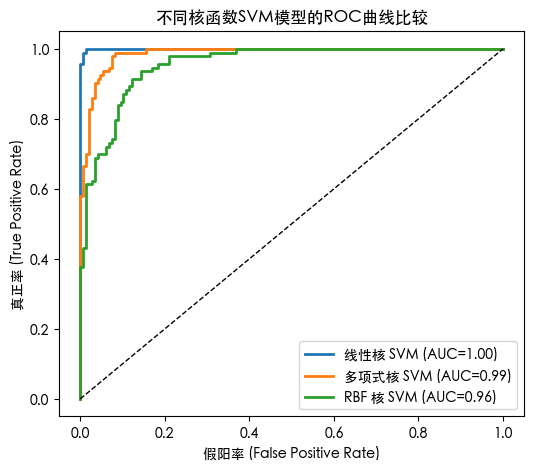

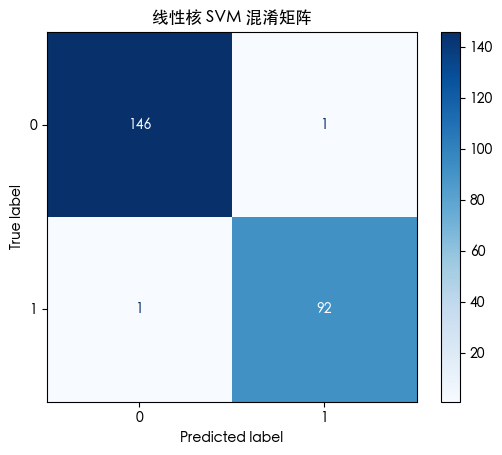

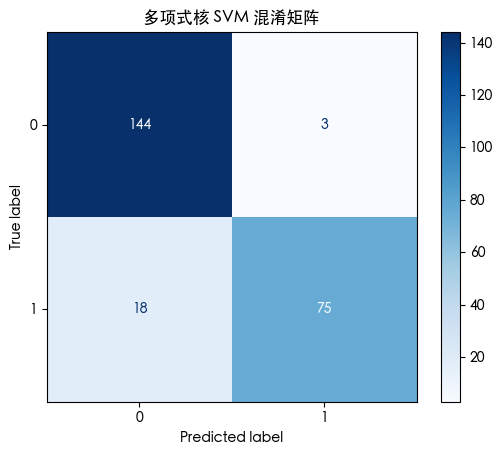

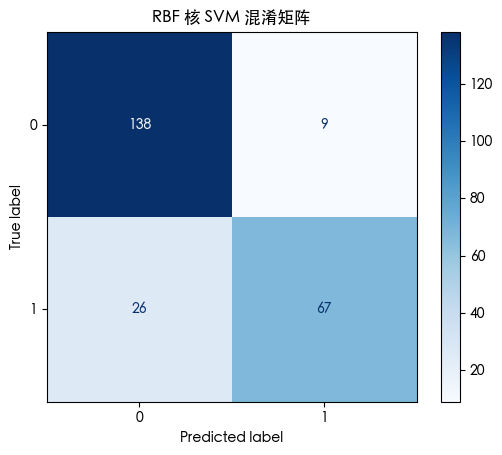

In [36]:
import matplotlib.pyplot as plt # (!!!) 1. 确保 plt 已导入
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    roc_curve, 
    auc, 
    RocCurveDisplay,
    confusion_matrix,         
    ConfusionMatrixDisplay    
)

models = {
    "线性核 SVM": svm_linear,
    "多项式核 SVM": svm_poly,
    "RBF 核 SVM": svm_rbf
}

results = {}
plt.figure(figsize=(6,5))
ax_roc = plt.gca() 

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"\n {name} 准确率: {acc:.3f}")
    print(classification_report(y_test, y_pred))
    
    # 绘制ROC曲线
    y_score = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc:.2f})") # (!!!) 4. 确保画在 ax_roc 上

    # 绘制独立的混淆矩阵 
    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=model.classes_)
    disp.plot(cmap='Blues', colorbar=True) 
    plt.title(f"{name} 混淆矩阵") 

# ROC 曲线可视化 (确保在 ax_roc 上操作)
ax_roc.plot([0,1], [0,1], 'k--', lw=1)
ax_roc.set_xlabel("假阳率 (False Positive Rate)")
ax_roc.set_ylabel("真正率 (True Positive Rate)")
ax_roc.set_title("不同核函数SVM模型的ROC曲线比较")
ax_roc.legend()
plt.show() 

--- 开始网格搜索 ---
将要尝试的 C 值: [1.e-01 1.e+00 1.e+01 1.e+02 1.e+03]
将要尝试的 gamma 值: [1.e-03 1.e-02 1.e-01 1.e+00 1.e+01]
总共要训练的模型数量: 125 (5折交叉验证)
Fitting 5 folds for each of 25 candidates, totalling 125 fits

--- 网格搜索完成 ---
找到的最佳参数 (Best Parameters): {'C': 1000.0, 'gamma': 0.001}
最佳交叉验证准确率 (Best Score): 0.984

--- 使用“最佳模型”在“测试集”上评估 ---
最终测试集准确率: 0.979

最终测试集分类报告:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       147
           1       0.98      0.97      0.97        93

    accuracy                           0.98       240
   macro avg       0.98      0.98      0.98       240
weighted avg       0.98      0.98      0.98       240


最终测试集混淆矩阵:


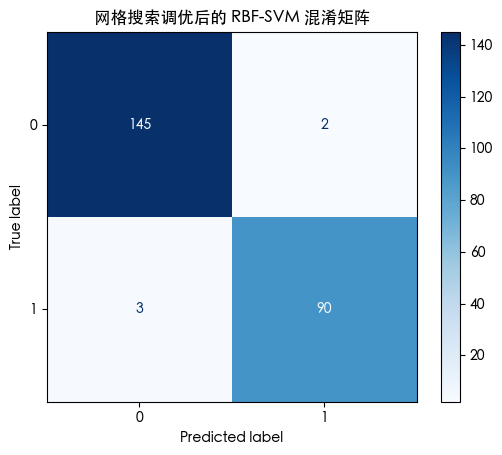

In [38]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# 定义要搜索的参数网格
param_grid = {
    'C': np.logspace(-1, 3, 5), 
    'gamma': np.logspace(-3, 1, 5)
}

print("--- 开始网格搜索 ---")
print(f"将要尝试的 C 值: {param_grid['C']}")
print(f"将要尝试的 gamma 值: {param_grid['gamma']}")
print(f"总共要训练的模型数量: {len(param_grid['C']) * len(param_grid['gamma']) * 5} (5折交叉验证)")

# 初始化并运行网格搜索
svc = SVC(kernel='rbf')
grid_search = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2 
)
grid_search.fit(X_train, y_train)

print("\n--- 网格搜索完成 ---")
print(f"找到的最佳参数 (Best Parameters): {grid_search.best_params_}")
print(f"最佳交叉验证准确率 (Best Score): {grid_search.best_score_:.3f}")

# 使用“最佳模型”在“测试集”上进行最终评估

print("\n--- 使用“最佳模型”在“测试集”上评估 ---")
y_pred_best = grid_search.predict(X_test)

print(f"最终测试集准确率: {accuracy_score(y_test, y_pred_best):.3f}")

# 打印详细的分类报告 (召回率, F1分数等)
print("\n最终测试集分类报告:")
print(classification_report(y_test, y_pred_best))

# 绘制最终的混淆矩阵
print("\n最终测试集混淆矩阵:")
cm = confusion_matrix(y_test, y_pred_best, labels=grid_search.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=grid_search.classes_)
disp.plot(cmap='Blues', colorbar=True)
plt.title("网格搜索调优后的 RBF-SVM 混淆矩阵")
plt.show()

正在训练模型并绘制边界...


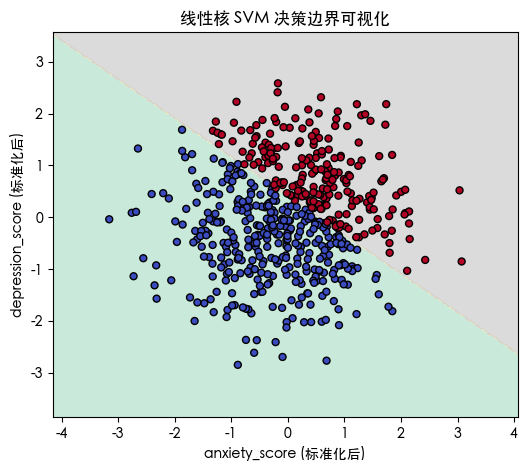

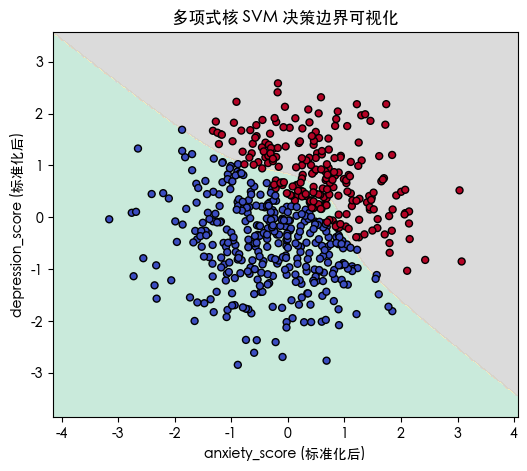

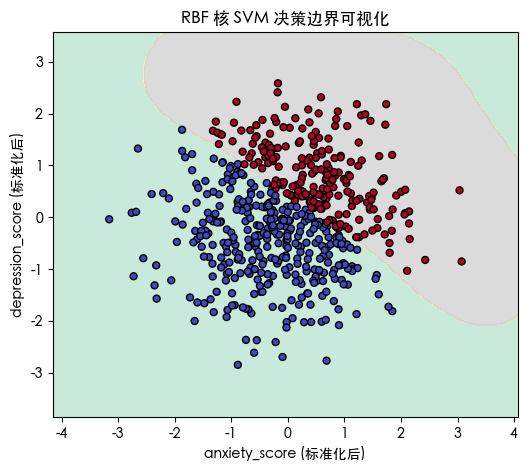

In [40]:
FEATURE_1 = "anxiety_score"
FEATURE_2 = "depression_score"
TARGET = "risk"

# 检查列是否存在
required_cols = [FEATURE_1, FEATURE_2, TARGET]
if not all(col in df.columns for col in required_cols):
    print(f"错误: df 中缺少以下列之一: {required_cols}")
    print("请检查你的 preprocessing.py 文件和 CSV 文件。")
else:
    df_2d = df[required_cols].copy()
    X_2d = df_2d[[FEATURE_1, FEATURE_2]].values
    y_2d = df_2d[TARGET].values


    #  标准化 + 划分数据
    scaler2 = StandardScaler()
    X_2d_scaled = scaler2.fit_transform(X_2d)

    X_train2, X_test2, y_train2, y_test2 = train_test_split(
        X_2d_scaled, y_2d, 
        test_size=0.3, 
        random_state=42, 
        stratify=y_2d
    )

    # 三种核函数模型 (使用你之前的参数)
    svm_linear = SVC(kernel='linear', C=1)
    svm_poly   = SVC(kernel='poly', degree=3, gamma='auto', C=1)
    svm_rbf    = SVC(kernel='rbf', gamma=0.5, C=1)

    models_2d = {
        "线性核 SVM": svm_linear,
        "多项式核 SVM": svm_poly,
        "RBF 核 SVM": svm_rbf
    }

    # 绘制决策边界函数
    def plot_decision_boundary(model, X, y, title):
        h = 0.02  # 网格步长
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                             np.arange(y_min, y_max, h))
        
        # 使用 np.c_ 来组合网格点
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        plt.figure(figsize=(6,5))
        # 绘制决策区域
        plt.contourf(xx, yy, Z, cmap=plt.cm.Pastel2, alpha=0.7)
        
        # 绘制数据点
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, s=25, edgecolors='k')
        
        plt.title(title)
        plt.xlabel(f"{FEATURE_1} (标准化后)")
        plt.ylabel(f"{FEATURE_2} (标准化后)")
        plt.show()

    # 训练并绘图
    for name, model in models_2d.items():
        model.fit(X_train2, y_train2)
        plot_decision_boundary(model, X_train2, y_train2, f"{name} 决策边界可视化")


### 由第三部分和第四部分可以看出，线性核函数最适合这个案例，它的ROC和准确度都相对更高。这个模型的意义是，给了学生学业压力、睡眠质量等数据，可以利用SVM模型来判断这个学生心理风险水平。